In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#전체매장데이터 불러오기
df=pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/전체매장데이터.csv', encoding='utf-8')
df.head(5)

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,구매시각,반품일자,구매월,구매일,구매시간대,반품소요기간
0,2023-01-06,220954944,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3829,매장A,10:32:00,NaN,1,6,10,0
1,2023-01-06,89023040,정상회원,채소,열매채소,단호박/손질,단호박(깍뚝썰기/300g),1.0,4977,매장A,10:41:00,NaN,1,6,10,0
2,2023-01-06,354941440,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:00:00,NaN,1,6,11,0
3,2023-01-06,786634048,탈퇴,반찬,어묵/묵,묵,도토리묵(420g:1모),1.0,7083,매장A,11:28:00,NaN,1,6,11,0
4,2023-01-06,438543104,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,11:59:00,NaN,1,6,11,0


# RFM 분석

* RFM 분석을 하는 이유?  
  - 기존 등급의 문제점 발견 : 기존 vip 분포가 매우 적음(전체의 1.7%)
    - 기존 vip 구매 패턴과 일반 고객 구매 패턴의 특징이 두드러지지 않음

- R : Recency : 얼마나 최근에 구매했는지
- F : Frequency : 얼마나 자주 구매했는지
- M: Monetary : 얼마나 많은 소비를 했는지


## RFM 지표 기획

In [ ]:
from re import A
from PIL import Image


### Recency
- 고객의 가장 마지막 구매일을 구함
- 데이터가 11월 4일까지
- 11월 5일 기준으로 마지막 구매일을 빼기
- minmax Scaler 후 1에서 값 빼기  : 최근성은 값이 작을 수록 좋은 것.

In [ ]:
# ▶ 고객ID별 가장 마지막 구매일
recency_df = df.groupby('회원번호',as_index=False)['공급일자'].max()
recency_df.columns = ['회원번호','LastPurchaseDate']
recency_df.head()

,회원번호,LastPurchaseDate
0,18613824,2023-07-08
1,18764160,2023-08-27
2,18792000,2023-04-09
3,18942336,2023-10-24
4,18949760,2023-10-04


In [ ]:
df['공급일자'].max()

'2023-11-04'

In [ ]:
# '공급일자' 컬럼을 datetime 형식으로 변환
df['공급일자'] = pd.to_datetime(df['공급일자'])

max_date = df['공급일자'].max()

# max_date의 다음 날짜 계산
next_day = max_date + pd.Timedelta(days=1)

In [ ]:
next_day

Timestamp('2023-11-05 00:00:00')

In [ ]:
#▶ 고객의 가장 마지막 구매일로 부터 몇일이 지났는지를 계산하기 위함
# '공급일자' 컬럼을 datetime 형식으로 변환
df['공급일자'] = pd.to_datetime(df['공급일자'])

# 'LastPurchaseDate' 컬럼을 datetime 형식으로 변환
recency_df['LastPurchaseDate'] = pd.to_datetime(recency_df['LastPurchaseDate'])

# 고객의 가장 마지막 구매일로부터 하루 지난 일 기준으로 경과 일수 계산
recency_df['Recency'] = (next_day - recency_df['LastPurchaseDate']).dt.days
recency_df.head(5)

,회원번호,LastPurchaseDate,Recency
0,18613824,2023-07-08,120
1,18764160,2023-08-27,70
2,18792000,2023-04-09,210
3,18942336,2023-10-24,12
4,18949760,2023-10-04,32


###  Frequency

In [ ]:
# ▶ Customer ID당 유니크한 Invoice를 1개의 주문건으로 인식하여 얼마나 자주 구매하고 있는지를 파악
frequency_df = df.copy()
frequency_df.drop_duplicates(subset=['회원번호','구매일','구매월','구매시간대'], keep="first", inplace=True)
frequency_df = frequency_df.groupby('회원번호', as_index=False)['회원번호'].value_counts()
frequency_df.columns = ['회원번호','Frequency']
frequency_df.head()

,회원번호,Frequency
0,18613824,1
1,18764160,8
2,18792000,1
3,18942336,12
4,18949760,1


### Monetary

In [ ]:
# ▶ 구매금액 = 구매개수 * 구매단가
# 각 회원번호별로 총 구매금액을 계산
df['Total_cost'] =  df['구매금액']
monetary_df = df.groupby('회원번호', as_index=False)['Total_cost'].sum()
monetary_df.columns = ['회원번호', 'Monetary']
monetary_df.head()


,회원번호,Monetary
0,18613824,21059
1,18764160,-88827
2,18792000,33311
3,18942336,560920
4,18949760,2776


In [ ]:
# ▶ Data merge

# ▶ recency and frequency
rf = recency_df.merge(frequency_df,how='left',on='회원번호')

# ▶ monetary

rfm = rf.merge(monetary_df,how='left',on='회원번호')

rfm.head(5)

,회원번호,LastPurchaseDate,Recency,Frequency,Monetary
0,18613824,2023-07-08,120,1,21059
1,18764160,2023-08-27,70,8,-88827
2,18792000,2023-04-09,210,1,33311
3,18942336,2023-10-24,12,12,560920
4,18949760,2023-10-04,32,1,2776


#### Scaling Data

In [ ]:
# ▶ Min max scale = 최대값을 1, 최소값을 0으로 표준화하는 기법
from sklearn.preprocessing import minmax_scale

# ▶ 최근성은 숫자가 작을수록, 즉 최근 구매일이 얼마 지나지 않은 고객이 더 점수가 높음
rfm['Recency'] = minmax_scale(rfm['Recency'], axis=0, copy=True)
rfm['Recency'] = 1-rfm['Recency']

rfm['Frequency'] = minmax_scale(rfm['Frequency'], axis=0, copy=True)

rfm['Monetary'] = minmax_scale(rfm['Monetary'], axis=0, copy=True)

# ▶ Score
# ▶ Score
rfm['Score'] = rfm['Recency'] * 0.3 + rfm['Frequency'] * 0.4 + rfm['Monetary'] * 0.3


# ▶ Score scaling 100 socre
rfm

,회원번호,LastPurchaseDate,Recency,Frequency,Monetary,Score
0,18613824,2023-07-08,0.605960,0.000000,0.033343,0.191791
1,18764160,2023-08-27,0.771523,0.008140,0.025197,0.242272
2,18792000,2023-04-09,0.307947,0.000000,0.034251,0.102660
3,18942336,2023-10-24,0.963576,0.012791,0.073364,0.316198
4,18949760,2023-10-04,0.897351,0.000000,0.031988,0.278802
...,...,...,...,...,...,...
11550,1644772352,2023-11-03,0.996689,0.000000,0.038083,0.310432
11551,1644957952,2023-11-03,0.996689,0.000000,0.033641,0.309099
11552,1670400000,2023-11-04,1.000000,1.000000,1.000000,1.000000
11553,1670606016,2023-10-16,0.937086,0.005814,0.041362,0.295860


In [ ]:
# ▶ 100점을 곱해서 100점 만점으로 scaling
rfm['Score']=minmax_scale(rfm['Score'], axis=0, copy=True)*100
rfm['Score']=round(rfm['Score'],0)
rfm.head(5)

,회원번호,LastPurchaseDate,Recency,Frequency,Monetary,Score
0,18613824,2023-07-08,0.605960,0.000000,0.033343,18.0
1,18764160,2023-08-27,0.771523,0.008140,0.025197,23.0
2,18792000,2023-04-09,0.307947,0.000000,0.034251,9.0
3,18942336,2023-10-24,0.963576,0.012791,0.073364,31.0
4,18949760,2023-10-04,0.897351,0.000000,0.031988,27.0


(array([1.364e+03, 1.814e+03, 4.219e+03, 4.022e+03, 1.260e+02, 7.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

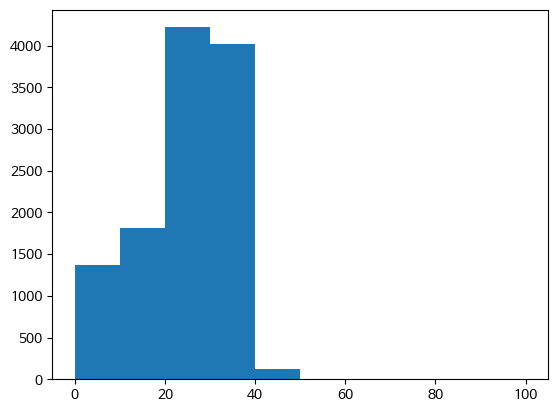

In [ ]:
plt.hist(rfm['Score'])

In [ ]:
rfm['Score'].describe()

count    11555.000000
mean        23.969624
std          9.499261
min          0.000000
25%         18.000000
50%         27.000000
75%         31.000000
max        100.000000
Name: Score, dtype: float64

## 고객 등급 나누기 (4개)

In [ ]:
#상위 5퍼 vvip
#상위 20퍼 vip
#상위 50퍼 gold

# 스코어의 분위수 계산
q1 = rfm['Score'].quantile(0.95)
q2 = rfm['Score'].quantile(0.85)
q3 = rfm['Score'].quantile(0.5)

# 등급을 설정하는 함수
def set_grade(score):
    if score >= q1:
        return 'vvip'
    elif score >= q2:
        return 'vip'
    elif score >= q3:
        return 'gold'
    else:
        return 'green'

# 각 스코어에 대해 등급 설정
rfm['Grade'] = rfm['Score'].apply(set_grade)

# 결과 출력
rfm.head(5)

,회원번호,LastPurchaseDate,Recency,Frequency,Monetary,Score,Grade
0,18613824,2023-07-08,0.605960,0.000000,0.033343,18.0,green
1,18764160,2023-08-27,0.771523,0.008140,0.025197,23.0,green
2,18792000,2023-04-09,0.307947,0.000000,0.034251,9.0,green
3,18942336,2023-10-24,0.963576,0.012791,0.073364,31.0,gold
4,18949760,2023-10-04,0.897351,0.000000,0.031988,27.0,gold


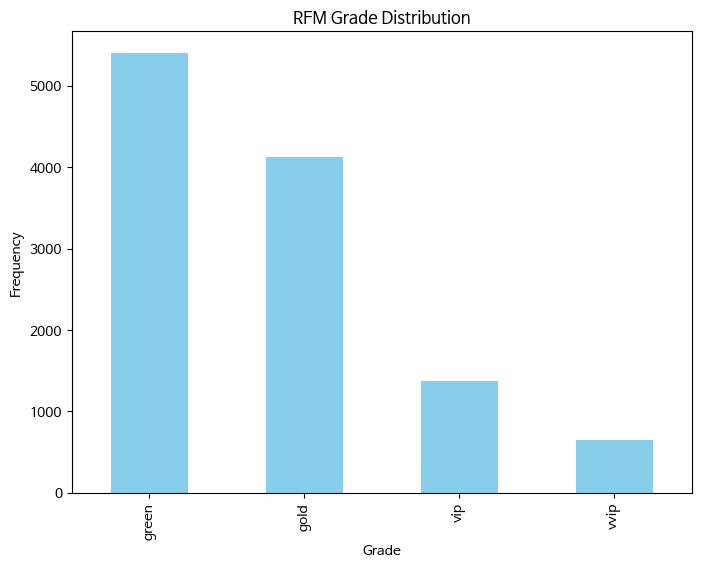

In [ ]:
# 등급별 빈도 계산
grade_counts = rfm['Grade'].value_counts()

# 막대 그래프 생성
plt.figure(figsize=(8, 6))
grade_counts.plot(kind='bar', color='skyblue')

# 그래프 제목과 축 레이블 추가
plt.title('RFM Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Frequency')

# 그래프 표시
plt.show()

새로 고객 등급 나뉜걸, 구매, 멤버 데이터와 합치기ㅁ

- 멤버 데이터와 합치고 csv 로 저장

In [ ]:
member = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/finmem.csv')


In [ ]:
finalmem = pd.merge(member, rfm[['회원번호', 'Grade']], on='회원번호')

finalmem

,회원번호,조합원상태,시,주소,성별,연령,연령대,배송서비스신청여부,모바일알람여부,Gold_member,Grade
0,1000012800,정상회원,용인,수지구-풍덕천동,여,58.0,50대,미신청,.,normal,green
1,1000103744,정상회원,용인,처인구-고림동,여,34.0,30대,미신청,.,normal,gold
2,1000122304,정상회원,광주,광주-기타,여,38.0,30대,미신청,.,normal,gold
3,1000163136,정상회원,용인,수지구-동천동,여,73.0,70대,미신청,.,normal,gold
4,1000281920,정상회원,용인,수지구-풍덕천동,여,42.0,40대,신청,.,normal,gold
...,...,...,...,...,...,...,...,...,...,...,...
11550,999682432,탈퇴,용인,수지구-동천동,여,47.0,40대,미신청,.,normal,green
11551,999721408,정상회원,용인,수지구-동천동,여,43.0,40대,미신청,.,normal,green
11552,999738112,정상회원,용인,수지구-성복동,여,67.0,60대,미신청,.,normal,gold
11553,999754816,정상회원,용인,수지구-상현동,여,44.0,40대,신청,.,normal,vip


In [ ]:
finalmem.to_csv("realfinalmem.csv")

In [ ]:
df = pd.merge(df, rfm, how='left', on='회원번호')
df.head(5)

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,...,구매일,구매시간대,반품소요기간,Total_cost,LastPurchaseDate,Recency,Frequency,Monetary,Score,Grade
0,2023-01-06,220954944,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3829,매장A,...,6,10,0,3829,2023-11-03,0.996689,0.101163,0.264622,41.0,vvip
1,2023-01-06,89023040,정상회원,채소,열매채소,단호박/손질,단호박(깍뚝썰기/300g),1.0,4977,매장A,...,6,10,0,4977,2023-11-03,0.996689,0.025581,0.080900,33.0,vip
2,2023-01-06,354941440,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,...,6,11,0,7083,2023-08-14,0.728477,0.011628,0.040503,23.0,green
3,2023-01-06,786634048,탈퇴,반찬,어묵/묵,묵,도토리묵(420g:1모),1.0,7083,매장A,...,6,11,0,7083,2023-01-12,0.019868,0.003488,0.036253,1.0,green
4,2023-01-06,438543104,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,...,6,11,0,7083,2023-09-13,0.827815,0.011628,0.039857,26.0,green


### 새로운 등급별 분석

In [ ]:
vvip = df[df['Grade'] == 'vvip']
vip = df[df['Grade'] == 'vip']
gold = df[df['Grade'] == 'gold']
green = df[df['Grade']== 'green']

In [ ]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = vvip.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = vvip.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 총 구매 금액, 평균구매금액과 최고구매금액 계산
customer_purchase_summary = vvip.groupby('회원번호').agg({
    '구매금액': ['sum','mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['총구매금액','평균구매금액', '최고구매금액']


# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
vvip_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary], axis=1)

# 결과 출력
vvip_info

,구매금액,물품대분류,물품중분류,물품소분류,총구매금액,평균구매금액,최고구매금액
회원번호,,,,,,,
19627200,1788851,채소,잎/줄기채소,스낵,1788851,11846.695364,53650
19996544,1286488,채소,잎/줄기채소,유정란,1286488,11589.981982,169617
20588608,2774143,간식,소,한우,2774143,12552.683258,64324
22270144,2104267,축산물,유제품,우유/산양유,2104267,10736.056122,302477
24883392,2121359,채소,쌈채소류,냉동생선,2121359,10150.043062,91892
...,...,...,...,...,...,...,...
1563577920,1194784,채소,잎/줄기채소,두부,1194784,7028.141176,48052
1565649216,1391013,채소,열매채소,스낵,1391013,9659.812500,44414
1566343360,1865579,축산물,중량(정육),돼지(중량),1865579,13046.006993,70642


In [ ]:
vvip_info['총구매금액'].sum()

1221608994

In [ ]:
vvip_info['총구매금액'].mean()

1885199.0648148148

In [ ]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = vip.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = vip.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 평균구매금액과 최고구매금액 계산
customer_purchase_summary = vip.groupby('회원번호').agg({
    '구매금액': ['sum','mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['총구매금액','평균구매금액', '최고구매금액']



# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
vip_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary], axis=1)

# 결과 출력
vip_info

,구매금액,물품대분류,물품중분류,물품소분류,총구매금액,평균구매금액,최고구매금액
회원번호,,,,,,,
28394944,645639,채소,잎/줄기채소,김가공,645639,10584.245902,49392
31691200,597586,간식,과자,스낵,597586,10671.178571,64133
37584000,665065,채소,빵,"식빵, 식사대용",665065,9367.112676,48052
38808960,1527220,채소,밀가공,두부,1527220,17354.772727,378097
38862784,542637,채소,열매채소,애호박,542637,11796.456522,59347
...,...,...,...,...,...,...,...
1601037568,692060,간식,빵,녹용,692060,36424.210526,248874
1612813888,503269,채소,열매채소,기름,503269,10484.770833,29566
1618521088,311763,축산물,음료,두유,311763,8660.083333,34459


In [ ]:
vip_info['총구매금액'].sum()

898132492

In [ ]:
vip_info['총구매금액'].mean()

653187.2669090909

In [ ]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = gold.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = gold.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 평균구매금액과 최고구매금액 계산
customer_purchase_summary = gold.groupby('회원번호').agg({
    '구매금액': ['sum','mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['총구매금액','평균구매금액', '최고구매금액']


# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
gold_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary], axis=1)

# 결과 출력
gold_info

,구매금액,물품대분류,물품중분류,물품소분류,총구매금액,평균구매금액,최고구매금액
회원번호,,,,,,,
18942336,560920,축산물,과일,기초화장품,560920,17528.750000,70833
18949760,2776,반찬,두부/유부,두부,2776,2776.000000,2776
19727424,116110,채소,잎/줄기채소,깐마늘,116110,9675.833333,22399
20235968,164449,채소,콩나물,콩나물,164449,10963.266667,31205
20636864,380759,채소,두부/유부,두부,380759,6241.950820,40203
...,...,...,...,...,...,...,...
1644557056,27951,양념/가루,가루,생강,27951,13975.500000,21059
1644705536,22973,생활용품,화장품,기초화장품,22973,22973.000000,22973
1644772352,85000,수산,냉동수산,기타냉동수산,85000,42500.000000,49583


In [ ]:
gold_info['총구매금액'].mean()

192361.37809015997

In [ ]:
# 1. 고객별로 구매금액을 합산하여 총구매금액 계산
total_purchase_amount = green.groupby('회원번호')['구매금액'].sum()

# 2. 고객별로 구매한 물품들의 대분류, 중분류, 소분류를 기록
customer_purchase_categories = green.groupby('회원번호').agg({
    '물품대분류': lambda x: x.mode()[0],  # 가장 많이 구매한 대분류
    '물품중분류': lambda x: x.mode()[0],  # 가장 많이 구매한 중분류
    '물품소분류': lambda x: x.mode()[0]   # 가장 많이 구매한 소분류
})

# 3. 각 고객의 구매 내역을 요약하여 1인당 평균구매금액과 최고구매금액 계산
customer_purchase_summary = green.groupby('회원번호').agg({
    '구매금액': ['sum','mean', 'max']  # 1인당 평균구매금액과 최고구매금액
})
customer_purchase_summary.columns = ['총구매금액','평균구매금액', '최고구매금액']


# 고객별 총구매금액, 가장 많이 구매한 물품 대분류, 중분류, 소분류 정보를 합치기
green_info = pd.concat([total_purchase_amount, customer_purchase_categories, customer_purchase_summary], axis=1)

# 결과 출력
green_info

,구매금액,물품대분류,물품중분류,물품소분류,총구매금액,평균구매금액,최고구매금액
회원번호,,,,,,,
18613824,21059,생활용품,생활용품,위생용품,21059,21059.000000,21059
18764160,-88827,생활용품,생활용품,위생용품,-88827,-8882.700000,21059
18792000,33311,축산물,중량(정육),한우(중량),33311,33311.000000,33311
19391488,3159,채소,쌈채소류,로메인,3159,3159.000000,3159
20258240,3063,채소,열매채소,풋고추,3063,3063.000000,3063
...,...,...,...,...,...,...,...
1631871296,149485,축산물,중량(정육),한우(중량),149485,74742.500000,116021
1632598848,15890,주곡,찹쌀,찹쌀,15890,15890.000000,15890
1633159360,4977,반찬,밑반찬,김가공,4977,4977.000000,4977


In [ ]:
#green 평균 구매
green_info['총구매금액'].mean()

63213.44635590085

### 시각화

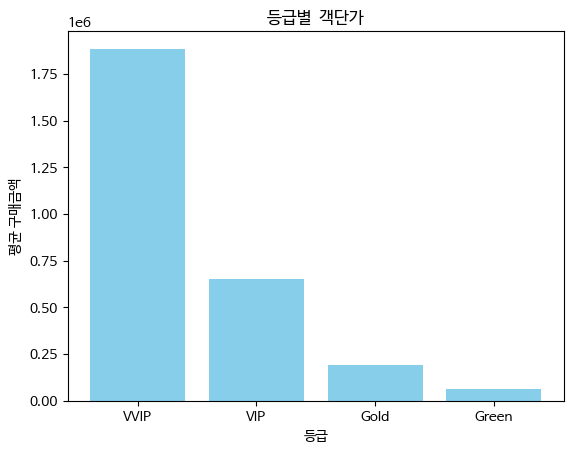

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 네 가지 그룹의 평균 구매금액 계산
mean_vvip = vvip_info['총구매금액'].mean()
mean_vip = vip_info['총구매금액'].mean()
mean_gold = gold_info['총구매금액'].mean()
mean_green = green_info['총구매금액'].mean()

# 시각화
groups = ['VVIP', 'VIP', 'Gold', 'Green']
mean_values = [mean_vvip, mean_vip, mean_gold, mean_green]
colors = ['skyblue', 'skyblue', 'skyblue', 'skyblue']

plt.bar(groups, mean_values, color=colors)
plt.xlabel('등급')
plt.ylabel('평균 구매금액')
plt.title('등급별  객단가')
plt.show()


In [ ]:
df

,공급일자,회원번호,조합원상태,물품대분류,물품중분류,물품소분류,물품명,구매수량,구매금액,구매매장,...,구매일,구매시간대,반품소요기간,Total_cost,LastPurchaseDate,Recency,Frequency,Monetary,Score,Grade
0,2023-01-06,220954944,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3829,매장A,...,6,10,0,3829,2023-11-03,0.996689,0.101163,0.264622,41.0,vvip
1,2023-01-06,89023040,정상회원,채소,열매채소,단호박/손질,단호박(깍뚝썰기/300g),1.0,4977,매장A,...,6,10,0,4977,2023-11-03,0.996689,0.025581,0.080900,33.0,vip
2,2023-01-06,354941440,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,...,6,11,0,7083,2023-08-14,0.728477,0.011628,0.040503,23.0,green
3,2023-01-06,786634048,탈퇴,반찬,어묵/묵,묵,도토리묵(420g:1모),1.0,7083,매장A,...,6,11,0,7083,2023-01-12,0.019868,0.003488,0.036253,1.0,green
4,2023-01-06,438543104,정상회원,축산물,알,유정란,유정란/매장용(10알/국내산),1.0,7083,매장A,...,6,11,0,7083,2023-09-13,0.827815,0.011628,0.039857,26.0,green
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294640,2023-11-04,560448896,정상회원,주곡,멥쌀,멥쌀,백미/유(2kg),1.0,15315,매장D,...,4,13,0,15315,2023-11-04,1.000000,0.059302,0.102025,35.0,vvip
294641,2023-11-04,68976384,정상회원,채소,잎/줄기채소,시금치,시금치(300g),2.0,6892,매장D,...,4,11,0,6892,2023-11-04,1.000000,0.037209,0.167785,36.0,vvip
294642,2023-11-04,1519813440,정상회원,반찬,밑반찬,김가공,구운자른김(15g*3봉),1.0,7466,매장D,...,4,14,0,7466,2023-11-04,1.000000,0.052326,0.108248,35.0,vvip
294643,2023-11-04,654809792,정상회원,반찬,두부/유부,두부,두부(1모:420g),1.0,3733,매장D,...,4,16,0,3733,2023-11-04,1.000000,0.033721,0.079674,33.0,vip


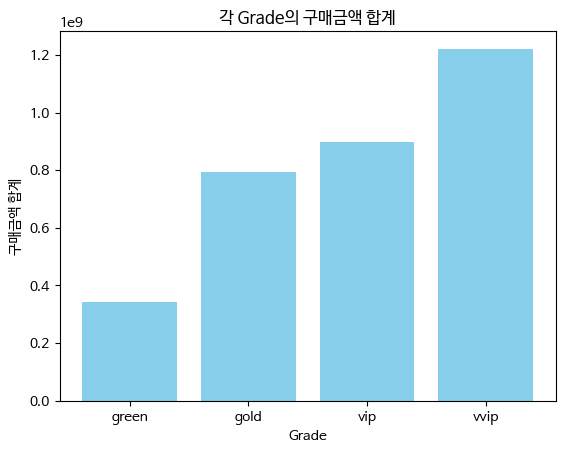

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 각 등급에 대한 구매금액 합계를 계산하여 데이터프레임으로 만들기
grade_purchase_sum = df.groupby('Grade')['구매금액'].sum().reset_index()

# 구매금액을 기준으로 오름차순으로 데이터프레임 정렬
grade_purchase_sum = grade_purchase_sum.sort_values(by='구매금액')

# 시각화
plt.bar(grade_purchase_sum['Grade'], grade_purchase_sum['구매금액'], color='skyblue')
plt.xlabel('Grade')
plt.ylabel('구매금액 합계')
plt.title('각 Grade의 구매금액 합계')
plt.show()


In [ ]:
df.groupby('Grade')['구매금액'].sum()


Grade
gold      793683046
green     341731891
vip       898132492
vvip     1221608994
Name: 구매금액, dtype: int64

등급별 많이 구매된 물품

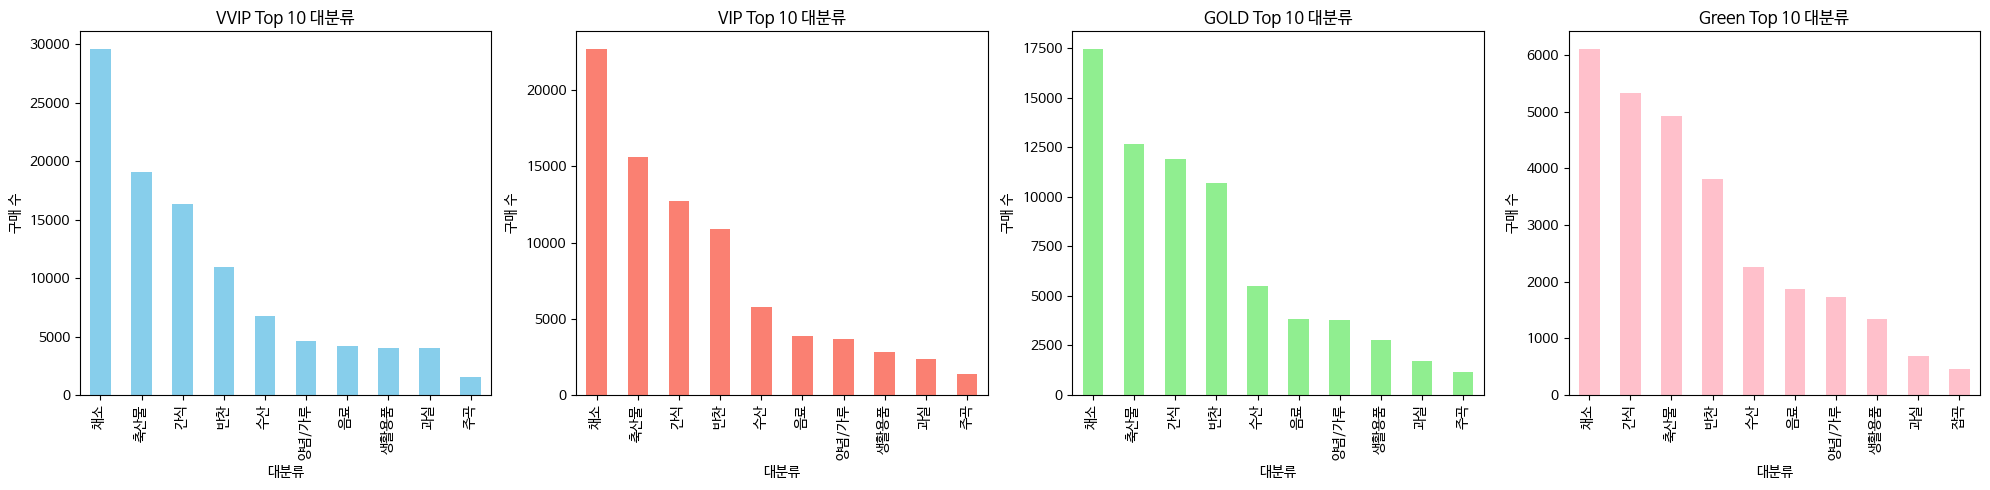

In [ ]:
# 가장 많이 구매된 물품 대분류 추출
top_categories = vvip.groupby('물품대분류').size().nlargest(10)
topvip_categories = vip.groupby('물품대분류').size().nlargest(10)
topgold_categories = gold.groupby('물품대분류').size().nlargest(10)
topgreen_categories = green.groupby('물품대분류').size().nlargest(10)

# 그래프 그리기
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
top_categories.plot(kind='bar', color='skyblue')
plt.title('VVIP Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

plt.subplot(1, 4, 2)
topvip_categories.plot(kind='bar', color='salmon')
plt.title('VIP Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

plt.subplot(1, 4, 3)
topgold_categories.plot(kind='bar', color='lightgreen')
plt.title('GOLD Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

plt.subplot(1, 4, 4)
topgreen_categories.plot(kind='bar', color='pink')
plt.title('Green Top 10 대분류')
plt.xlabel('대분류')
plt.ylabel('구매 수')

plt.tight_layout()
plt.show()

In [ ]:
print("vvip:",top_categories)
print("vip:",topvip_categories)
print("gold:",topgold_categories)
print("green:",topgreen_categories)

vvip: 물품대분류
채소       29635
축산물      19071
간식       16363
반찬       10976
수산        6765
양념/가루     4606
음료        4223
생활용품      4015
과실        3994
주곡        1578
dtype: int64
vip: 물품대분류
채소       22733
축산물      15601
간식       12709
반찬       10914
수산        5794
음료        3878
양념/가루     3666
생활용품      2841
과실        2356
주곡        1350
dtype: int64
gold: 물품대분류
채소       17488
축산물      12691
간식       11918
반찬       10707
수산        5519
음료        3855
양념/가루     3802
생활용품      2792
과실        1727
주곡        1169
dtype: int64
green: 물품대분류
채소       6109
간식       5327
축산물      4920
반찬       3803
수산       2258
음료       1874
양념/가루    1732
생활용품     1342
과실        681
잡곡        461
dtype: int64
